	AUTHOR:[UZAIR-UR-REHMAN]

# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [15]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [16]:
checkpoints = r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [17]:
train_dir = r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\train'
validation_dir = r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\validation'
test_dir = r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\test'

DATA FOLLOW SEQUENCE IN SEQUENTIAL.MODEL  BUT FOLLOW PARALLEL PATTEN IN MODEL.API

In [18]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

c:\Users\PMLS\anaconda3\envs\DSP\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

WORK  DONE STEPS:0-data path , 1-DATA (train , validation, test) ,  2-MODEL MAKING , 3-MODEL COMPILING(loss, optimizer, class) , 4-checkpoint ,5-model filt.6-accuracy and loss graph , 7-model test and confusion matrix

Model compilation : 3 step (loss , optimizer and matrix)

In [20]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

MORE THAN 2 CLASSES THAN USE CATEGORICAL CLASSS::: AND BATCH SIZE DEPEND ON COMPUTER RAM

In [21]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


chk data at different point ::: checkpooint ftn :::: and path where data save

In [22]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

model fit

In [23]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=50,
                   callbacks=callbacks)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.4144 - loss: 1.2762
Epoch 1: val_loss improved from None to 0.63803, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0001-loss0.64.h5



Epoch 1: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0001-loss0.64.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - acc: 0.5356 - loss: 1.0776 - val_acc: 0.7540 - val_loss: 0.6380
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7191 - loss: 0.7065
Epoch 2: val_loss did not improve from 0.63803
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - acc: 0.7294 - loss: 0.6515 - val_acc: 0.5556 - val_loss: 0.9270
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7547 - loss: 0.5574
Epoch 3: val_loss improved from 0.63803 to 0.45064, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0003-loss0.45.h5



Epoch 3: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0003-loss0.45.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - acc: 0.7719 - loss: 0.5274 - val_acc: 0.7659 - val_loss: 0.4506
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8058 - loss: 0.4383
Epoch 4: val_loss improved from 0.45064 to 0.41028, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0004-loss0.41.h5



Epoch 4: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0004-loss0.41.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - acc: 0.7975 - loss: 0.4457 - val_acc: 0.8056 - val_loss: 0.4103
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8204 - loss: 0.3991
Epoch 5: val_loss improved from 0.41028 to 0.37665, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0005-loss0.38.h5



Epoch 5: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0005-loss0.38.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - acc: 0.8263 - loss: 0.3830 - val_acc: 0.8294 - val_loss: 0.3767
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8645 - loss: 0.3405
Epoch 6: val_loss did not improve from 0.37665
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - acc: 0.8519 - loss: 0.3486 - val_acc: 0.7302 - val_loss: 0.5985
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8475 - loss: 0.3455
Epoch 7: val_loss improved from 0.37665 to 0.28746, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0007-loss0.29.h5


...


Epoch 8: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0008-loss0.28.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - acc: 0.8744 - loss: 0.2742 - val_acc: 0.8730 - val_loss: 0.2782
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8826 - loss: 0.2684
Epoch 9: val_loss did not improve from 0.27820
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - acc: 0.8813 - loss: 0.2711 - val_acc: 0.8730 - val_loss: 0.2934
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9066 - loss: 0.2168
Epoch 10: val_loss improved from 0.27820 to 0.27360, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0010-loss0.27.h5



Epoch 10: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0010-loss0.27.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - acc: 0.8956 - loss: 0.2360 - val_acc: 0.8849 - val_loss: 0.2736
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9050 - loss: 0.2101
Epoch 11: val_loss improved from 0.27360 to 0.22749, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0011-loss0.23.h5



Epoch 11: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0011-loss0.23.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - acc: 0.9000 - loss: 0.2238 - val_acc: 0.8929 - val_loss: 0.2275
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9253 - loss: 0.1794
Epoch 12: val_loss did not improve from 0.22749
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - acc: 0.9206 - loss: 0.1889 - val_acc: 0.9048 - val_loss: 0.2289
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9168 - loss: 0.2128
Epoch 13: val_loss did not improve from 0.22749
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - acc: 0.9250 - loss: 0.1882 - val_acc: 0.8929 - val_loss: 0.2392
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9387 - loss: 0.1657
Epoch 14: val_loss improved from 0.22749 to 0.20938, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0014-loss0.21.h5



Epoch 14: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0014-loss0.21.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - acc: 0.9356 - loss: 0.1666 - val_acc: 0.8968 - val_loss: 0.2094
Epoch 15/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9532 - loss: 0.1344
Epoch 15: val_loss did not improve from 0.20938
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - acc: 0.9481 - loss: 0.1435 - val_acc: 0.9087 - val_loss: 0.2411
Epoch 16/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9498 - loss: 0.1382
Epoch 16: val_loss did not improve from 0.20938
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - acc: 0.9525 - loss: 0.1407 - val_acc: 0.8770 - val_loss: 0.2720
Epoch 17/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9630 - loss: 0.1115
Epoch 17: val_loss improved from 0.20938 to 0.19412, saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0017-loss0.19.h5



Epoch 17: finished saving model to D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\DATASET\E1-cp-0017-loss0.19.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - acc: 0.9588 - loss: 0.1153 - val_acc: 0.9087 - val_loss: 0.1941
Epoch 18/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9631 - loss: 0.1106
Epoch 18: val_loss did not improve from 0.19412
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - acc: 0.9625 - loss: 0.1122 - val_acc: 0.9167 - val_loss: 0.2041
Epoch 19/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9714 - loss: 0.0856
Epoch 19: val_loss did not improve from 0.19412
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - acc: 0.9675 - loss: 0.0899 - val_acc: 0.8730 - val_loss: 0.2836
Epoch 20/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9704 - loss: 0.0817
Epoch 20: val_loss did not improve from 0.19412
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - acc: 0.9737 - loss: 0.0802 - val_acc: 0.9087 - val_loss: 0.2071
Epoch 21/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9779 - loss: 0.0810
E

In [24]:
model_history.history

{'acc': [0.5356249809265137,
  0.7293750047683716,
  0.7718750238418579,
  0.7975000143051147,
  0.8262500166893005,
  0.8518750071525574,
  0.856249988079071,
  0.8743749856948853,
  0.8812500238418579,
  0.8956249952316284,
  0.8999999761581421,
  0.9206249713897705,
  0.925000011920929,
  0.9356250166893005,
  0.9481250047683716,
  0.9524999856948853,
  0.9587500095367432,
  0.9624999761581421,
  0.9674999713897705,
  0.9737499952316284,
  0.9737499952316284,
  0.9862499833106995,
  0.9818750023841858,
  0.9943749904632568,
  0.9837499856948853,
  0.9900000095367432,
  0.9956250190734863,
  0.9956250190734863,
  0.9912499785423279,
  0.9956250190734863,
  0.9925000071525574,
  1.0,
  0.9943749904632568,
  1.0,
  0.9962499737739563,
  1.0,
  0.9950000047683716,
  1.0,
  1.0,
  0.9975000023841858,
  1.0,
  0.9981250166893005,
  1.0,
  1.0,
  0.9950000047683716,
  1.0,
  0.9900000095367432,
  1.0,
  1.0,
  0.9956250190734863],
 'loss': [1.0776143074035645,
  0.6514647603034973,
  0.527

1-accuracy and 2-validation accuracy and 3-loss and 4-valdiation accuracy

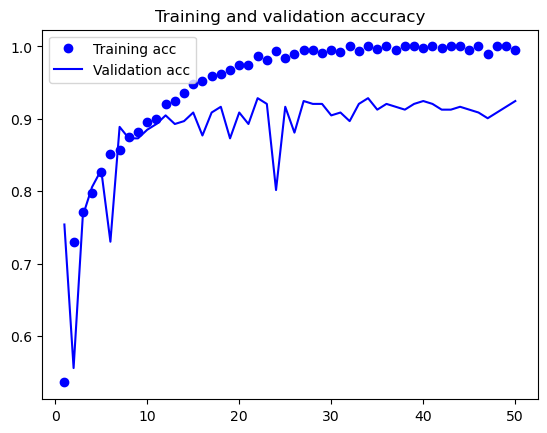

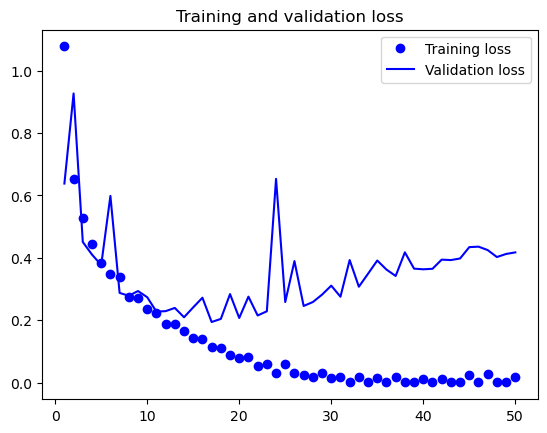

<Figure size 640x480 with 0 Axes>

In [25]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\model_Accuracy.png')

In [26]:
model.save(r'D:\UNIVERSITY\8 SEMESTER\MACHINE LEARNING LAB\LAB 7\E1-cp-0012-loss0.21.h5')

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 571ms/step


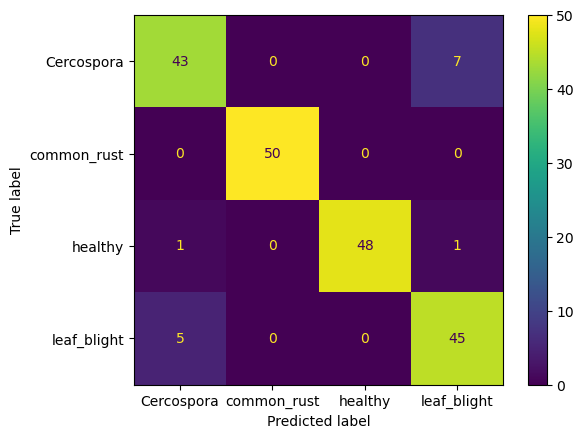

In [27]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [28]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.88      0.86      0.87        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      0.96      0.98        50
 leaf_blight       0.85      0.90      0.87        50

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



WORK  DONE STEPS:0-data path , 1-DATA (train , validation, test) ,  2-MODEL MAKING , 3-MODEL COMPILING(loss, optimizer, class) , 4-checkpoint ,5-model filt.6-accuracy and loss graph , 7-model test and confusion matrix